<a href="https://colab.research.google.com/github/snjy-r13/DEEP-LEARNING-24BAD407/blob/main/EX-1/ANN_REGRESSION_24BAD407.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import libraries
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import fetch_california_housing

def name():
  print("SANJAY - 24BAD407")


In [2]:
# 2. Load California Housing dataset
name()
california_housing = fetch_california_housing()
X = california_housing.data
y = california_housing.target

print("Dataset loaded successfully.")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print("Features names:", california_housing.feature_names)
print("Target name:", california_housing.target_names)


SANJAY - 24BAD407
Dataset loaded successfully.
Number of samples: 20640
Number of features: 8
Features names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target name: ['MedHouseVal']


In [3]:
# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
name()
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

SANJAY - 24BAD407
Training set size: 16512 samples
Testing set size: 4128 samples


In [4]:
# 4. Standardize the features
name()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized successfully.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

SANJAY - 24BAD407
Features standardized successfully.
X_train_scaled shape: (16512, 8)
X_test_scaled shape: (4128, 8)


In [5]:
# 5. Build ANN model
name()
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) # Output layer for regression (single value prediction)
])

model.summary()


SANJAY - 24BAD407


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 6. Compile the model
name()
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

print("Model compiled successfully.")

SANJAY - 24BAD407
Model compiled successfully.


In [7]:
# 7. Train the model
name()
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0 # Set verbose to 0 to suppress training output
)

print("Model training complete.")

SANJAY - 24BAD407
Model training complete.


In [8]:
# 8. Predict house prices
name()
y_pred = model.predict(X_test_scaled)

print("Predictions made successfully.")
print(f"Shape of predictions: {y_pred.shape}")

SANJAY - 24BAD407
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions made successfully.
Shape of predictions: (4128, 1)


SANJAY - 24BAD407
Mean Squared Error (MSE): 0.2784
Mean Absolute Error (MAE): 0.3463
Root Mean Squared Error (RMSE): 0.5276


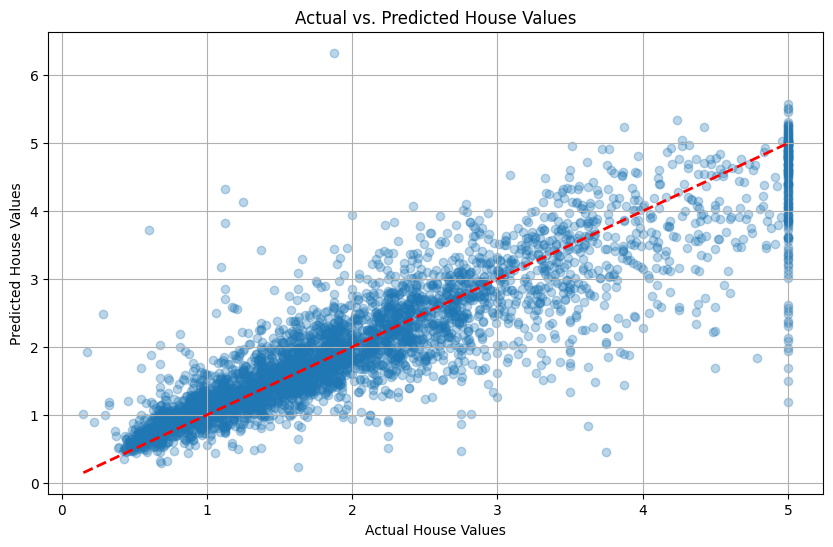

In [9]:
# 9. Evaluate using MSE, MAE, RMSE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse) # RMSE is the square root of MSE
name()
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Optionally, visualize predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Actual vs. Predicted House Values")
plt.grid(True)
plt.show()